In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')


SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 07 · Xếp hạng đặc trưng trên Val, và tinh chỉnh cho 30 cột

Notebook 05 kết luận DR-Learner chạy trên **30 cột** không tệ hơn bản 69 cột. Nhưng thứ hạng
đặc trưng dùng để chọn ra 30 cột đó được đo bằng permutation importance **trên `rct_select`**
(notebook 04b). Nếu lại lấy `rct_select` ra làm bằng chứng để đổi bản bàn giao, thì đang dùng
chính tập đã dùng để chọn làm tập để chứng minh — lập luận vòng tròn, và thiên vị nghiêng về
phía bản 30 cột.

Notebook này dựng lại thứ hạng đặc trưng **trên tập Val**, bằng đúng bộ máy pseudo-outcome
doubly robust của notebook 03. Val là dữ liệu quan sát, chưa từng dùng để ra quyết định nào về
đặc trưng. Khi thứ hạng đến từ Val, `rct_select` trở lại là tập giữ ngoài thật sự cho phép so
30-vs-69 ở notebook 08 — và không tốn lần mở `rct_holdout` nào.

**Notebook này làm ba việc:**

1. Đo permutation importance của 69 đặc trưng trên vùng overlap của Val, chấm bằng `dr_qini`.
2. Đối chiếu thứ hạng đó với thứ hạng của 04b — mức trùng nhau tự nó là một phép kiểm.
3. Tinh chỉnh siêu tham số **riêng DR-Learner** trên tập 30 cột dẫn xuất từ Val. Con số `k=30`
   hiện tại của notebook 05 chạy bằng siêu tham số tinh chỉnh cho **69 cột**, tức bản 30 cột
   đang bị chấp; đây là bước gỡ chấp.

**Notebook này KHÔNG làm:**

- Không nạp `rct_holdout.parquet`.
- Không nạp `rct_select.parquet` — nó không cần tới, và không đụng vào thì càng dễ kiểm.
- Không quét lại `k`. `k = 30` là hằng số cho trước, thừa kế từ notebook 05. Quét lại là thêm
  một lần chọn nữa.
- Không chạy lại vòng đấu 6 mô hình. Trên `rct_select` khoảng cách giữa mô hình nhất và bét là
  `0.021` trong khi KTC bootstrap của **một** mô hình đã rộng `±0.025`, và **0/5** so sánh theo
  cặp có KTC khác 0; trên `rct_holdout` quán quân DR-Learner xếp **6/6**. Một "quán quân mới"
  chọn trên 30 cột sẽ là kết quả tung đồng xu.

# Phần 1 — Thiết lập

### Bước 1 — Thư viện và đường dẫn

Kaggle không cài sẵn `mlflow`, mà notebook này cần nó để ghi vết 12 trial tinh chỉnh. Notebook
03 — notebook duy nhất khác có dùng `optuna` + `mlflow` — cài chúng ở ngay ô đầu; ở đây làm
đúng như vậy. Chạy local thì `uv sync --frozen` đã lo, không cài gì thêm.

In [2]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q optuna mlflow')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use 

In [3]:
import os
import json
import time
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

import optuna
import mlflow

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    _train_files = glob.glob('/kaggle/input/**/train.parquet', recursive=True)
    if not _train_files:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra dataset source.')
    ROOT = '/kaggle/working'
    DATA_DIR = os.path.dirname(_train_files[0])
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


def tim_file(ten):
    '''Tìm artifact local hoặc trong output của kernel nguồn trên Kaggle.'''
    ung_vien = [os.path.join(ART_DIR, ten)]
    if IS_KAGGLE:
        ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        raise FileNotFoundError(
            f'Không tìm thấy {ten}. Kiểm tra kernel_sources của notebook 07.')
    if len(ung_vien) > 1:
        print(f'!!! Có {len(ung_vien)} bản {ten}; đang dùng: {ung_vien[0]}')
    return ung_vien[0]


SEED = 42
np.random.seed(SEED)

# np.trapz đã đổi tên ở NumPy 2 — dùng bản nào có sẵn (giống notebook 03/05)
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')

# Kaggle không có font phủ dấu tiếng Việt nên tiêu đề biểu đồ ra ô vuông (xem figure 20 và 21
# của các lần chạy trước). DejaVu Sans đi kèm chính matplotlib nên máy nào cũng có, và nó phủ đủ.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] + plt.rcParams['font.sans-serif']

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print('Môi trường :', 'Kaggle' if IS_KAGGLE else 'Local')
print('DATA_DIR   :', DATA_DIR)
print('ART_DIR    :', ART_DIR)
print('rct_holdout: KHÔNG nạp')
print('rct_select : KHÔNG nạp')

Môi trường : Kaggle
DATA_DIR   : /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR    : /kaggle/working/artifacts
rct_holdout: KHÔNG nạp
rct_select : KHÔNG nạp


### Bước 2 — Chế độ chạy

In [4]:
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

# k = 30 là HẰNG SỐ CHO TRƯỚC, thừa kế từ notebook 05. Không quét lại ở đây.
K_CHOT = 30

if SMOKE_TEST:
    N_TUNE, N_VAL, N_TRIALS, N_XAO, N_BOOT = 20_000, 10_000, 2, 2, 100
else:
    N_TUNE, N_VAL, N_TRIALS, N_XAO, N_BOOT = 200_000, 100_000, 12, 5, 1_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 70)
print(f'  07 — XẾP HẠNG ĐẶC TRƯNG TRÊN VAL   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Tinh chỉnh trên      : {N_TUNE:,} dòng | Val {N_VAL:,} dòng')
print(f'  Số lần xáo mỗi cột   : {N_XAO}')
print(f'  Trial cho DR-Learner : {N_TRIALS}  (chỉ DR-Learner, không đụng 5 mô hình còn lại)')
print(f'  Bootstrap            : {N_BOOT:,} lần')
print(f'  k chốt               : {K_CHOT}  (cho trước, không quét lại)')
if SMOKE_TEST:
    print('  >>> CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 70)

  07 — XẾP HẠNG ĐẶC TRƯNG TRÊN VAL   |   CHẾ ĐỘ: FULL
  Tinh chỉnh trên      : 200,000 dòng | Val 100,000 dòng
  Số lần xáo mỗi cột   : 5
  Trial cho DR-Learner : 12  (chỉ DR-Learner, không đụng 5 mô hình còn lại)
  Bootstrap            : 1,000 lần
  k chốt               : 30  (cho trước, không quét lại)


### Bước 3 — Nạp dữ liệu và các quyết định đã chốt

Ngưỡng trim `alpha` **đọc lại** từ `best_params.json` chứ không tính lại bằng quy tắc Crump.
Lý do: estimand của thước đo là `E[tau(X) | alpha <= e(X) <= 1-alpha]`. Nếu hai notebook tự
tính ra hai `alpha` khác nhau thì chúng đang nói về hai đại lượng khác nhau, và con số hết so
được với nhau.

In [5]:
tuning69 = json.load(open(tim_file('best_params.json'), encoding='utf-8'))
P_DR69 = tuning69['best_params']['DRLearner']['params']

E_ALPHA = float(tuning69['xu_ly_overlap']['propensity_alpha'])
E_CLIP = (E_ALPHA, 1 - E_ALPHA)
WINSOR_P = float(tuning69['xu_ly_overlap']['winsorize_phan_vi'][0])

select_meta = json.load(open(tim_file('04b_select_meta.json'), encoding='utf-8'))
HANG_SELECT = select_meta['permutation_importance']['hang']

quet = json.load(open(tim_file('quet_dac_trung.json'), encoding='utf-8'))
TOP_K_SELECT = quet['dac_trung_o_muc_chot']

finfo = json.load(open(tim_file('feature_info.json'), encoding='utf-8'))
FEATS = finfo['tat_ca_dac_trung']
N_FEAT = len(FEATS)

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))

# Chốt cổng
assert N_FEAT == 69, f'feature_info.json khai {N_FEAT} đặc trưng, phải là 69'
assert not any(f.startswith('fe_') for f in FEATS), 'Còn sót đặc trưng dẫn xuất fe_*'
assert set(HANG_SELECT) == set(FEATS), 'Thứ hạng của 04b không khớp danh sách đặc trưng'
assert len(TOP_K_SELECT) == K_CHOT, f'quet_dac_trung.json chốt {len(TOP_K_SELECT)} cột, không phải {K_CHOT}'

print(f'Train              : {len(train):>8,} dòng')
print(f'Val                : {len(val):>8,} dòng')
print(f'Đặc trưng          : {N_FEAT} cột gốc đã làm sạch')
print()
print(f'Siêu tham số 69 cột: {P_DR69}')
print(f'Ngưỡng trim alpha  : {E_ALPHA}  (đọc lại từ notebook 03, không tính lại)')
print(f'Winsorize phân vị  : {WINSOR_P}% / {100 - WINSOR_P}%')
print()
print(f'Tập {K_CHOT} cột của notebook 05 (xếp hạng đo trên rct_select):')
print('  ' + ', '.join(TOP_K_SELECT))

Train              :  741,335 dòng
Val                :  185,334 dòng
Đặc trưng          : 69 cột gốc đã làm sạch

Siêu tham số 69 cột: {'n_estimators': 200, 'learning_rate': 0.04141536110538596, 'max_depth': 5, 'min_child_samples': 38}
Ngưỡng trim alpha  : 0.071  (đọc lại từ notebook 03, không tính lại)
Winsorize phân vị  : 0.5% / 99.5%

Tập 30 cột của notebook 05 (xếp hạng đo trên rct_select):
  f0, f1, f2, f3, f4, f5, f8, f9, f10, f12, f13, f16, f17, f18, f22, f23, f24, f25, f26, f27, f28, f29, f31, f34, f35, f37, f38, f40, f79, f80


# Phần 2 — Dựng lại bộ máy DR trên Val

Toàn bộ phần này là bản sao của notebook 03. Giữ nguyên công thức để hai notebook chấm điểm
bằng cùng một thước.

### Bước 4 — Mẫu tinh chỉnh và mẫu Val

In [6]:
def stratified_sample(df, n, seed=SEED):
    if n >= len(df):
        return df.reset_index(drop=True)
    key = df['is_treat'].astype(str) + '_' + df['label'].astype(str)
    return (df.groupby(key, group_keys=False)
              .apply(lambda g: g.sample(n=max(1, int(round(n * len(g) / len(df)))),
                                        random_state=seed))
              .reset_index(drop=True))


tune_df = stratified_sample(train, N_TUNE)
val_df = stratified_sample(val, N_VAL)

X_tune = tune_df[FEATS].values.astype(np.float64)
W_tune, Y_tune = tune_df['is_treat'].values, tune_df['label'].values
X_val = val_df[FEATS].values.astype(np.float64)
W_val, Y_val = val_df['is_treat'].values, val_df['label'].values

print(f'Tập tinh chỉnh: {len(tune_df):>7,} dòng | treat {W_tune.mean()*100:.2f}% '
      f'| mua {Y_tune.mean()*100:.2f}%')
print(f'Tập Val       : {len(val_df):>7,} dòng | treat {W_val.mean()*100:.2f}% '
      f'| mua {Y_val.mean()*100:.2f}%')

Tập tinh chỉnh: 200,000 dòng | treat 22.17% | mua 1.99%
Tập Val       : 100,000 dòng | treat 22.17% | mua 1.99%


### Bước 5 — Ba mô hình phụ, ước lượng bằng cross-fitting

In [7]:
def fit_nuisance(X, W, Y, n_folds=5, seed=SEED):
    '''Ước lượng ba mô hình phụ bằng cross-fitting. Trả về ê THÔ, chưa cắt.'''
    n = len(X)
    e_raw = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)

    strata = W * 2 + Y                      # giữ nguyên tỉ lệ 4 tổ hợp trong mỗi fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    nuisance_params = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                           min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in skf.split(X, strata):
        m_e = lgb.LGBMClassifier(**nuisance_params).fit(X[tr], W[tr])
        e_raw[te] = m_e.predict_proba(X[te])[:, 1]

        m0 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 0], Y[tr][W[tr] == 0])
        m1 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 1], Y[tr][W[tr] == 1])
        mu0_hat[te] = m0.predict_proba(X[te])[:, 1]
        mu1_hat[te] = m1.predict_proba(X[te])[:, 1]

    return e_raw, mu0_hat, mu1_hat


def dr_from_nuisance(W, Y, e_raw, mu0_hat, mu1_hat, clip):
    '''Ghép pseudo-outcome doubly robust từ ba mô hình phụ, cắt ê theo `clip`.'''
    e_hat = np.clip(e_raw, *clip)
    dr = ((mu1_hat - mu0_hat)
          + W * (Y - mu1_hat) / e_hat
          - (1 - W) * (Y - mu0_hat) / (1 - e_hat))
    return dr, e_hat


def compute_dr_scores(X, W, Y, n_folds=5, seed=SEED, clip=None):
    '''Bọc hai hàm trên lại — đây là hàm DR-Learner gọi ở Phần 3.'''
    clip = E_CLIP if clip is None else clip
    e_raw, mu0_hat, mu1_hat = fit_nuisance(X, W, Y, n_folds=n_folds, seed=seed)
    dr, e_hat = dr_from_nuisance(W, Y, e_raw, mu0_hat, mu1_hat, clip)
    return dr, e_hat, mu0_hat, mu1_hat


print('Đã định nghĩa fit_nuisance, dr_from_nuisance, compute_dr_scores')

Đã định nghĩa fit_nuisance, dr_from_nuisance, compute_dr_scores


### Bước 6 — Cross-fitting trên Val, trim, rồi winsorize

In [8]:
t0 = time.time()
e_raw_val, mu0_val, mu1_val = fit_nuisance(X_val, W_val, Y_val)
print(f'Cross-fitting xong sau {time.time()-t0:.1f} giây')

dr_full, _ = dr_from_nuisance(W_val, Y_val, e_raw_val, mu0_val, mu1_val, E_CLIP)
overlap = (e_raw_val >= E_ALPHA) & (e_raw_val <= 1 - E_ALPHA)

dr_ov = dr_full[overlap]              # CHƯA winsorize — dùng để báo cáo MỨC
X_val_ov = X_val[overlap]
W_val_ov = W_val[overlap]
Y_val_ov = Y_val[overlap]


def winsorize(v, p=WINSOR_P):
    '''Kéo p% đuôi mỗi bên về đúng phân vị đó.'''
    lo, hi = np.percentile(v, [p, 100 - p])
    return np.clip(v, lo, hi), float(lo), float(hi)


dr_val, WIN_LO, WIN_HI = winsorize(dr_ov)   # ĐÃ winsorize — nhãn cho thước đo XẾP HẠNG

print()
print(f'Val ban đầu   : {len(dr_full):>8,} dòng')
print(f'Sau khi trim  : {len(dr_ov):>8,} dòng  ({overlap.mean()*100:.2f}%)')
print(f'Cận winsorize : [{WIN_LO:.3f} ; {WIN_HI:.3f}]')
print(f'ATE_DR trên vùng overlap (từ dr_ov, chưa winsorize): {dr_ov.mean()*100:+.3f} pp')
print()
print('Estimand: E_Pval[tau(X) | alpha <= e(X) <= 1-alpha] — ATE trên VÙNG OVERLAP của Val,')
print('KHÔNG phải ATE trên toàn quần thể Val.')

Cross-fitting xong sau 25.8 giây

Val ban đầu   :  100,000 dòng
Sau khi trim  :   43,431 dòng  (43.43%)
Cận winsorize : [-1.258 ; 1.548]
ATE_DR trên vùng overlap (từ dr_ov, chưa winsorize): +0.444 pp

Estimand: E_Pval[tau(X) | alpha <= e(X) <= 1-alpha] — ATE trên VÙNG OVERLAP của Val,
KHÔNG phải ATE trên toàn quần thể Val.


### Bước 7 — Thước đo DR-AUUC

In [9]:
def _thu_tu(score, seed=SEED):
    '''Sắp giảm dần theo score, phá thế hòa ngẫu nhiên có seed.'''
    n = len(score)
    rng = np.random.RandomState(seed)
    return np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))


def dr_gain_curve(score, dr=None, seed=SEED):
    '''(x = tỉ lệ dân số được nhắm, g = uplift tích lũy trên mỗi người), có kèm điểm gốc (0,0).'''
    dr = dr_val if dr is None else dr
    order = _thu_tu(score, seed)
    n = len(dr)
    x = np.concatenate([[0.0], np.arange(1, n + 1) / n])
    g = np.concatenate([[0.0], np.cumsum(np.asarray(dr, dtype=float)[order]) / n])
    return x, g


def dr_auuc_tho(score, dr=None, seed=SEED):
    '''Diện tích giữa đường cong và đường chéo ngẫu nhiên — chưa chuẩn hóa.'''
    x, g = dr_gain_curve(score, dr, seed)
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def dr_qini(score, dr=None, seed=SEED):
    '''THƯỚC ĐO CHÍNH. Chuẩn hóa theo xếp hạng biết trước. Ngẫu nhiên ~ 0, biết trước = 1.'''
    dr = dr_val if dr is None else dr
    tran = dr_auuc_tho(dr, dr, seed)
    return dr_auuc_tho(score, dr, seed) / tran if tran > 0 else np.nan


print(f'Thước đo tính trên {len(dr_val):,} dòng thuộc vùng overlap của Val')

Thước đo tính trên 43,431 dòng thuộc vùng overlap của Val


### Bước 8 — Kiểm chứng thước đo trước khi tin nó

Bốn phép thử có `assert` chốt cổng. Nếu thước đo sai thì cả thứ hạng đặc trưng lẫn kết quả
tinh chỉnh ở dưới đều vô nghĩa, nên phải chặn ngay tại đây.

In [10]:
rng_kc = np.random.RandomState(SEED)

q_biet_truoc = dr_qini(dr_val)
q_nguoc = dr_qini(-dr_val)

q_rnd_nhieu_lan = np.array([dr_qini(rng_kc.randn(len(dr_val))) for _ in range(20)])
q_rnd_tb, q_rnd_sd = q_rnd_nhieu_lan.mean(), q_rnd_nhieu_lan.std()

muc_nhieu = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
nhieu = rng_kc.randn(len(dr_val))
thang = dr_val.std()
q_theo_nhieu = [dr_qini(dr_val + m * thang * nhieu) for m in muc_nhieu]
giam_don_dieu = bool(np.all(np.diff(q_theo_nhieu) <= 1e-12))

kiem_chung = pd.DataFrame([
    {'Phép thử': '1. Xếp hạng biết trước = 1,0',
     'Kết quả': f'{q_biet_truoc:.6f}', 'Đạt': abs(q_biet_truoc - 1.0) < 1e-9},
    {'Phép thử': '2. Xếp hạng ngược = -1,0',
     'Kết quả': f'{q_nguoc:.6f}', 'Đạt': abs(q_nguoc + 1.0) < 1e-9},
    {'Phép thử': '3. Ngẫu nhiên ~ 0 (TB 20 lần)',
     'Kết quả': f'{q_rnd_tb:+.4f} ± {q_rnd_sd:.4f}', 'Đạt': abs(q_rnd_tb) < 0.05},
    {'Phép thử': '4. Giảm đơn điệu theo nhiễu',
     'Kết quả': f'{q_theo_nhieu[0]:.3f} -> {q_theo_nhieu[-1]:.3f}', 'Đạt': giam_don_dieu},
])
display(kiem_chung)

assert kiem_chung['Đạt'].all(), 'Có phép kiểm chứng không đạt — sửa công thức trước khi đi tiếp'
print('✅ Thước đo qua cả bốn phép kiểm chứng.')

QINI_NGAU_NHIEN = float(q_rnd_tb)

,Phép thử,Kết quả,Đạt
0,"1. Xếp hạng biết trước = 1,0",1.000000,True
1,"2. Xếp hạng ngược = -1,0",-1.000000,True
2,3. Ngẫu nhiên ~ 0 (TB 20 lần),+0.0018 ± 0.0097,True
3,4. Giảm đơn điệu theo nhiễu,1.000 -> 0.239,True


✅ Thước đo qua cả bốn phép kiểm chứng.


# Phần 3 — Xếp hạng đặc trưng trên Val

### Bước 9 — Mô hình gốc: DR-Learner 69 cột

Dùng đúng siêu tham số đã chốt cho 69 cột. Đây là mô hình sẽ bị xáo từng cột ở bước sau —
cùng một mô hình cho mọi cột, nên chênh lệch chỉ đến từ cột bị xáo.

In [11]:
class DRLearner:
    '''Kennedy 2020 — hồi quy pseudo-outcome doubly robust. Bản sao từ notebook 03.'''
    def __init__(self, n_folds=5, **params):
        self.n_folds = n_folds
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        dr_train, *_ = compute_dr_scores(X, W, Y, n_folds=self.n_folds)
        self.model = lgb.LGBMRegressor(**self.params).fit(X, dr_train)
        return self

    def predict_cate(self, X):
        return self.model.predict(X)


t0 = time.time()
mo_hinh_goc = DRLearner(**P_DR69).fit(X_tune, W_tune, Y_tune)
cate_goc = mo_hinh_goc.predict_cate(X_val_ov)
QINI_GOC = dr_qini(cate_goc)

print(f'Huấn luyện xong sau {time.time()-t0:.1f} giây')
print(f'Qini_DR trên vùng overlap của Val: {QINI_GOC:+.4f}')
print(f'  (mốc xếp hạng ngẫu nhiên       : {QINI_NGAU_NHIEN:+.4f})')

Huấn luyện xong sau 52.1 giây
Qini_DR trên vùng overlap của Val: +0.0641
  (mốc xếp hạng ngẫu nhiên       : +0.0018)


### Bước 10 — Permutation importance: xáo từng cột, đo mức tụt Qini

Cùng cách làm với 04b, chỉ khác tập đo: 04b đo trên `rct_select`, ở đây đo trên vùng overlap
của Val. Mỗi cột bị xáo `N_XAO` lần rồi lấy trung bình mức tụt.

In [12]:
rng_perm = np.random.RandomState(SEED)
ket_qua_perm = []
Xp = X_val_ov.copy()
t0 = time.time()

for j, ten in enumerate(FEATS):
    goc = Xp[:, j].copy()
    tut = []
    for _ in range(N_XAO):
        col = goc.copy()
        rng_perm.shuffle(col)
        Xp[:, j] = col
        tut.append(QINI_GOC - dr_qini(mo_hinh_goc.predict_cate(Xp)))
    Xp[:, j] = goc                      # trả cột về nguyên trạng trước khi sang cột kế
    ket_qua_perm.append({'dac_trung': ten,
                         'giam_qini': float(np.mean(tut)),
                         'do_lech_chuan': float(np.std(tut))})
    if (j + 1) % 10 == 0 or j == len(FEATS) - 1:
        print(f'  {j+1:>2}/{len(FEATS)} cột | {time.time()-t0:.0f}s', flush=True)

assert np.allclose(Xp, X_val_ov), 'X_val_ov bị thay đổi sau vòng xáo — có lỗi khôi phục cột'
print(f'\nXong sau {(time.time()-t0)/60:.1f} phút.')

  10/69 cột | 10s
  20/69 cột | 20s
  30/69 cột | 30s
  40/69 cột | 40s
  50/69 cột | 50s
  60/69 cột | 60s
  69/69 cột | 69s

Xong sau 1.1 phút.


### Bước 11 — Bảng xếp hạng

In [13]:
df_perm = (pd.DataFrame(ket_qua_perm)
             .sort_values('giam_qini', ascending=False)
             .reset_index(drop=True))
df_perm.insert(0, 'hang', np.arange(1, len(df_perm) + 1))

XEP_HANG_VAL = list(df_perm['dac_trung'])
HANG_VAL = {r.dac_trung: int(r.hang) for r in df_perm.itertuples()}

# Tập k cột chốt, GIỮ THỨ TỰ CỘT GỐC (không phải thứ tự theo độ quan trọng) —
# feature_contract.json bắt buộc thứ tự cột gốc, sai chỗ này là hỏng bàn giao.
giu = set(XEP_HANG_VAL[:K_CHOT])
TOP_K_VAL = [f for f in FEATS if f in giu]

so_cot_giam = int((df_perm['giam_qini'] > 0).sum())

print(f'Số cột làm Qini TỤT khi bị xáo: {so_cot_giam}/{N_FEAT}')
print()
print(f'Tập {K_CHOT} cột theo xếp hạng Val:')
print('  ' + ', '.join(TOP_K_VAL))
print()
print('20 cột quan trọng nhất theo Val:')
display(df_perm.head(20).round(5))

Số cột làm Qini TỤT khi bị xáo: 44/69

Tập 30 cột theo xếp hạng Val:
  f0, f1, f3, f4, f5, f6, f7, f8, f9, f10, f13, f16, f17, f20, f21, f22, f23, f25, f26, f27, f28, f29, f35, f38, f42, f52, f60, f68, f80, f82

20 cột quan trọng nhất theo Val:


,hang,dac_trung,giam_qini,do_lech_chuan
0,1,f26,0.02391,0.00439
1,2,f22,0.02335,0.01296
2,3,f3,0.02044,0.00773
3,4,f16,0.01951,0.00563
4,5,f29,0.01686,0.00394
5,6,f80,0.01199,0.00304
6,7,f10,0.00886,0.00375
7,8,f4,0.00872,0.00375
8,9,f1,0.00689,0.00264
9,10,f28,0.00614,0.00215


# Phần 4 — Hai thứ hạng có nói cùng một chuyện không?

Đây là **phép kiểm, không phải quyết định**. Nếu top-30 dựng trên Val trùng nhiều với top-30
dựng trên `rct_select`, thì tập 30 cột là tín hiệu thật chứ không phải sản phẩm phụ của một
tập đo. Nếu trùng ít, đó là điều phải biết **trước** khi đổi bản bàn giao.

### Bước 12 — Tương quan hạng và độ trùng

In [14]:
# Cả hai đều là hạng nguyên 1..69 không có hạng đồng, nên hệ số tương quan Pearson trên
# dãy hạng CHÍNH LÀ Spearman — không cần scipy.
r_val = np.array([HANG_VAL[f] for f in FEATS], dtype=float)
r_select = np.array([HANG_SELECT[f] for f in FEATS], dtype=float)
rho = float(np.corrcoef(r_val, r_select)[0, 1])

bo_val, bo_select = set(TOP_K_VAL), set(TOP_K_SELECT)
trung = [f for f in FEATS if f in bo_val & bo_select]
chi_val = [f for f in FEATS if f in bo_val - bo_select]
chi_select = [f for f in FEATS if f in bo_select - bo_val]
SO_COT_TRUNG = len(trung)

print(f'Tương quan hạng Spearman (Val vs rct_select) trên cả {N_FEAT} cột : {rho:+.4f}')
print()
print(f'Độ trùng của hai tập {K_CHOT} cột: {SO_COT_TRUNG}/{K_CHOT} '
      f'({SO_COT_TRUNG/K_CHOT*100:.0f}%)')
print(f'  Chỉ có ở bản Val       ({len(chi_val)}): ' + (', '.join(chi_val) or '—'))
print(f'  Chỉ có ở bản rct_select ({len(chi_select)}): ' + (', '.join(chi_select) or '—'))
print()
if SO_COT_TRUNG >= 20:
    print('=> Hai tập đồng ý với nhau ở mức đáng kể. Tập 30 cột không phải sản phẩm phụ')
    print('   của riêng một tập đo.')
else:
    print('=> Hai tập đồng ý ÍT. Tập 30 cột phụ thuộc mạnh vào chỗ đo thứ hạng —')
    print('   phải nói rõ chuyện này trước khi đem đổi bản bàn giao.')

Tương quan hạng Spearman (Val vs rct_select) trên cả 69 cột : +0.3767

Độ trùng của hai tập 30 cột: 21/30 (70%)
  Chỉ có ở bản Val       (9): f6, f7, f20, f21, f42, f52, f60, f68, f82
  Chỉ có ở bản rct_select (9): f2, f12, f18, f24, f31, f34, f37, f40, f79

=> Hai tập đồng ý với nhau ở mức đáng kể. Tập 30 cột không phải sản phẩm phụ
   của riêng một tập đo.


### Bước 13 — Biểu đồ

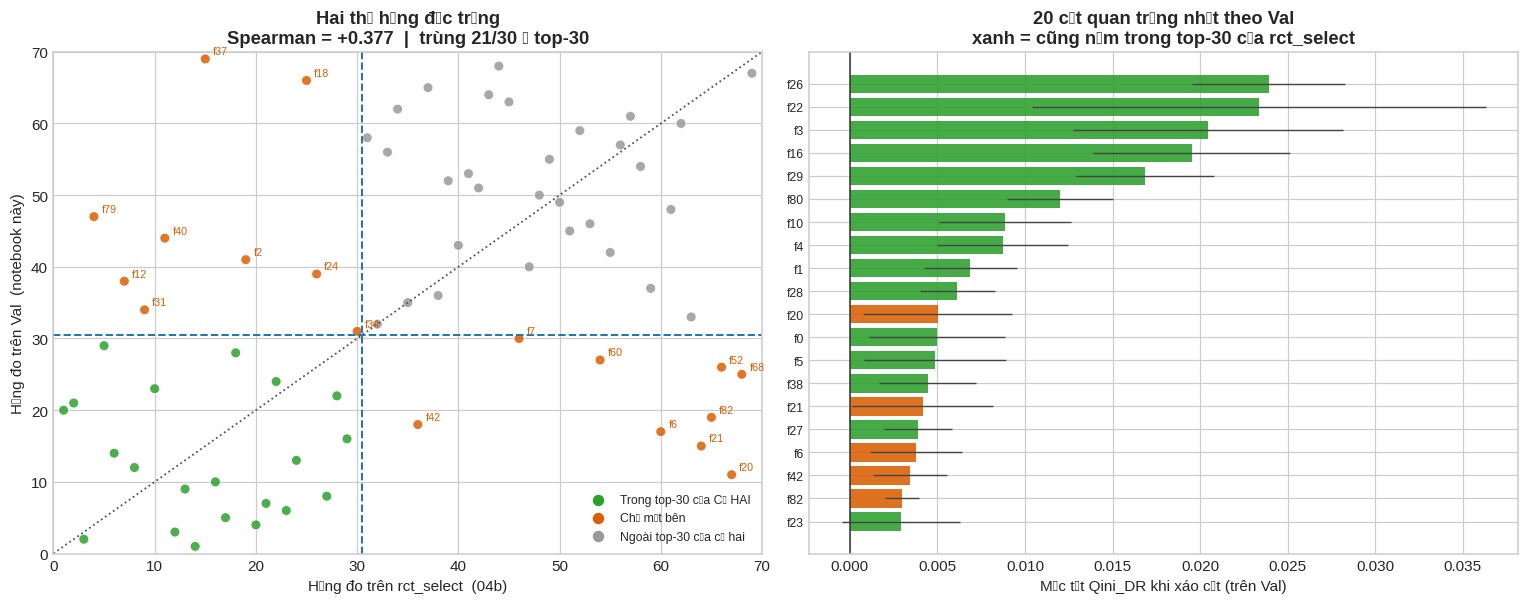

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# --- trái: hạng đối hạng ---------------------------------------------------
ax = axes[0]
mau = ['#2ca02c' if (f in bo_val and f in bo_select) else
       '#d95f02' if (f in bo_val) != (f in bo_select) else
       '#999999' for f in FEATS]
ax.scatter(r_select, r_val, c=mau, s=42, alpha=0.85, edgecolors='white', linewidths=0.6)
ax.plot([0, N_FEAT + 1], [0, N_FEAT + 1], ls=':', color='#555555', lw=1.2)
ax.axvline(K_CHOT + 0.5, color='#1f77b4', ls='--', lw=1.3)
ax.axhline(K_CHOT + 0.5, color='#1f77b4', ls='--', lw=1.3)

for f in FEATS:
    if (f in bo_val) != (f in bo_select):
        ax.annotate(f, (HANG_SELECT[f], HANG_VAL[f]), textcoords='offset points',
                    xytext=(5, 3), fontsize=7, color='#d95f02')

ax.set_xlabel('Hạng đo trên rct_select  (04b)')
ax.set_ylabel('Hạng đo trên Val  (notebook này)')
ax.set_title(f'Hai thứ hạng đặc trưng\nSpearman = {rho:+.3f}  |  trùng '
             f'{SO_COT_TRUNG}/{K_CHOT} ở top-{K_CHOT}')
ax.set_xlim(0, N_FEAT + 1)
ax.set_ylim(0, N_FEAT + 1)

for nhan, c in [(f'Trong top-{K_CHOT} của CẢ HAI', '#2ca02c'),
                ('Chỉ một bên', '#d95f02'),
                ('Ngoài top-30 của cả hai', '#999999')]:
    ax.scatter([], [], c=c, s=42, label=nhan)
ax.legend(fontsize=8, loc='lower right')

# --- phải: mức tụt Qini của 20 cột đầu -------------------------------------
ax = axes[1]
top = df_perm.head(20).iloc[::-1]
mau2 = ['#2ca02c' if f in bo_select else '#d95f02' for f in top['dac_trung']]
ax.barh(np.arange(len(top)), top['giam_qini'], xerr=top['do_lech_chuan'],
        color=mau2, alpha=0.88, error_kw=dict(lw=0.9, ecolor='#444444'))
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels(top['dac_trung'], fontsize=8)
ax.axvline(0, color='#333333', lw=1)
ax.set_xlabel('Mức tụt Qini_DR khi xáo cột (trên Val)')
ax.set_title(f'20 cột quan trọng nhất theo Val\nxanh = cũng nằm trong top-{K_CHOT} '
             f'của rct_select')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '27_hai_xep_hang.png'), bbox_inches='tight')
plt.show()

# Phần 5 — Tinh chỉnh DR-Learner trên 30 cột

Con số `k=30` của notebook 05 chạy bằng siêu tham số tinh chỉnh cho **69 cột**. Bản 30 cột
chưa từng được cấp cùng ngân sách tinh chỉnh mà bản 69 cột đã được cấp — đây là bước gỡ chấp.

Vòng này chạy **trên Val**, bằng DR-AUUC, đúng như notebook 03. Nó **không** đụng
`rct_select` và **không** đụng `rct_holdout`, nên không tạo thêm lần chọn nào trên hai tập
RCT.

### Bước 14 — Kết nối MLflow vào experiment riêng

Ghi vào experiment `lazada_cate_tuning_k30`, tách khỏi `lazada_cate_tuning` của notebook 03 —
66 run cũ là bằng chứng của bản 69 cột, không trộn vào được.

In [16]:
db_dir = '/kaggle/working' if IS_KAGGLE else ROOT
db_path = os.path.abspath(os.path.join(db_dir, 'mlflow.db'))

mlflow.set_tracking_uri(f'sqlite:///{db_path}')
mlflow.set_experiment('lazada_cate_tuning_k30')

print('Tracking URI:', mlflow.get_tracking_uri())
print('Experiment  : lazada_cate_tuning_k30')

2026/08/20 08:51:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/20 08:51:39 INFO mlflow.store.db.utils: Updating database tables
2026/08/20 08:51:43 INFO mlflow.tracking.fluent: Experiment with name 'lazada_cate_tuning_k30' does not exist. Creating a new experiment.


Tracking URI: sqlite:////kaggle/working/mlflow.db
Experiment  : lazada_cate_tuning_k30


### Bước 15 — Không gian tìm kiếm và vòng tinh chỉnh

Không gian tìm kiếm giữ **y hệt** notebook 03. Đổi không gian là đổi luôn phép so.

In [17]:
IDX_K30 = [i for i, f in enumerate(FEATS) if f in giu]
X_tune_k30 = X_tune[:, IDX_K30]
X_val_ov_k30 = X_val_ov[:, IDX_K30]

assert len(IDX_K30) == K_CHOT
assert [FEATS[i] for i in IDX_K30] == TOP_K_VAL


def suggest_params(trial):
    '''Y hệt không gian tìm kiếm của DR-Learner ở notebook 03.'''
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200, log=True),
    }


def tune_drlearner(n_trials):
    print(f'\n{"="*62}\n  DRLearner trên {K_CHOT} cột — {n_trials} trial\n{"="*62}')
    history = []
    giu_lai = {'q': -np.inf, 'cate': None, 'trial': None}

    def objective(trial):
        p = suggest_params(trial)
        t0 = time.time()
        try:
            model = DRLearner(**p).fit(X_tune_k30, W_tune, Y_tune)
            cate = model.predict_cate(X_val_ov_k30)
            if not np.all(np.isfinite(cate)):
                raise ValueError('CATE chứa giá trị không hữu hạn')
            q = dr_qini(cate)
            status = 'ok'
        except Exception as exc:
            print(f'  trial {trial.number}: LỖI — {type(exc).__name__}: {exc}')
            q, cate, status = -np.inf, None, f'lỗi: {type(exc).__name__}'

        elapsed = time.time() - t0
        if np.isfinite(q) and q > giu_lai['q']:
            giu_lai.update(q=q, cate=cate, trial=trial.number)

        with mlflow.start_run(run_name=f'DRLearner_k{K_CHOT}_trial{trial.number}'):
            mlflow.log_params(p)
            mlflow.set_tags({'model': 'DRLearner', 'run_mode': RUN_MODE, 'status': status,
                             'objective': 'dr_qini', 'feature_set': f'k{K_CHOT}_val_rank'})
            mlflow.log_metrics({
                'dr_qini': q if np.isfinite(q) else -1e9,
                'fit_seconds': elapsed,
                'cate_mean': float(np.mean(cate)) if cate is not None else 0.0,
                'cate_std': float(np.std(cate)) if cate is not None else 0.0,
            })
            mlflow.log_param('n_tune_rows', len(X_tune_k30))
            mlflow.log_param('n_val_overlap_rows', len(X_val_ov_k30))
            mlflow.log_param('n_features', K_CHOT)
            mlflow.log_param('propensity_alpha', E_ALPHA)
            mlflow.log_param('seed', SEED)

        history.append({'trial': trial.number, 'dr_qini': q, 'giây': elapsed, **p})
        print(f'  trial {trial.number}: Qini_DR = {q:+.4f} | {elapsed:.1f}s', flush=True)
        return q

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=f'DRLearner_k{K_CHOT}_{RUN_MODE}')
    study.optimize(objective, n_trials=n_trials)

    print(f'  -> Tốt nhất: Qini_DR = {study.best_value:+.4f} (trial {giu_lai["trial"]})')
    return study, pd.DataFrame(history), giu_lai['cate']


print(f'Ma trận tinh chỉnh: {X_tune_k30.shape} | chấm trên {X_val_ov_k30.shape}')

Ma trận tinh chỉnh: (200000, 30) | chấm trên (43431, 30)


### Bước 16 — Chạy tinh chỉnh

In [18]:
t_start = time.time()
study_k30, history_k30, cate_k30 = tune_drlearner(N_TRIALS)

assert cate_k30 is not None, 'Không có trial nào thành công — sửa lỗi rồi chạy lại'
assert len(study_k30.trials) == N_TRIALS

print(f'\nHoàn tất sau {(time.time()-t_start)/60:.1f} phút.')


  DRLearner trên 30 cột — 12 trial
  trial 0: Qini_DR = +0.0277 | 38.4s
  trial 1: Qini_DR = +0.0594 | 36.8s
  trial 2: Qini_DR = +0.0469 | 38.1s
  trial 3: Qini_DR = +0.0626 | 39.4s
  trial 4: Qini_DR = +0.0529 | 38.3s
  trial 5: Qini_DR = +0.0630 | 39.4s
  trial 6: Qini_DR = +0.0361 | 38.2s
  trial 7: Qini_DR = +0.0620 | 39.6s
  trial 8: Qini_DR = +0.0398 | 38.1s
  trial 9: Qini_DR = +0.0523 | 39.5s
  trial 10: Qini_DR = +0.0547 | 40.4s
  trial 11: Qini_DR = +0.0522 | 40.7s
  -> Tốt nhất: Qini_DR = +0.0630 (trial 5)

Hoàn tất sau 7.8 phút.


### Bước 17 — Khoảng tin cậy bootstrap, và so với bản 69 cột trên chính tập Val

Đây **chưa phải** phép so chốt — phép so chốt nằm ở notebook 08, trên `rct_select`. Bảng này
chỉ để biết vòng tinh chỉnh có tìm được gì hơn không, đo trên chính tập nó tối ưu.

In [19]:
def boot_qini(cate, n_boot=N_BOOT, seed=SEED):
    '''Bootstrap theo dòng của vùng overlap Val. Lấy lại cùng bộ chỉ số cho mọi mô hình
       thì phần dao động chung do lấy mẫu bị khử — cùng cách làm với notebook 03.'''
    rng = np.random.RandomState(seed)
    n = len(cate)
    out = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        out[b] = dr_qini(np.asarray(cate)[idx], dr_val[idx])
    return out


t0 = time.time()
rng_pair = np.random.RandomState(SEED)
n_ov = len(dr_val)
hieu = np.empty(N_BOOT)
q69_b = np.empty(N_BOOT)
q30_b = np.empty(N_BOOT)

for b in range(N_BOOT):
    idx = rng_pair.randint(0, n_ov, n_ov)
    q69_b[b] = dr_qini(cate_goc[idx], dr_val[idx])
    q30_b[b] = dr_qini(np.asarray(cate_k30)[idx], dr_val[idx])
    hieu[b] = q30_b[b] - q69_b[b]

lo69, hi69 = np.percentile(q69_b, [2.5, 97.5])
lo30, hi30 = np.percentile(q30_b, [2.5, 97.5])
lo_h, hi_h = np.percentile(hieu, [2.5, 97.5])
QINI_K30_VAL = float(study_k30.best_value)

display(pd.DataFrame([
    {'Bản': f'69 cột (hparam 69)', 'Qini_DR': QINI_GOC, 'KTC thấp': lo69, 'KTC cao': hi69},
    {'Bản': f'{K_CHOT} cột (hparam {K_CHOT})', 'Qini_DR': QINI_K30_VAL,
     'KTC thấp': lo30, 'KTC cao': hi30},
]).round(5))

print(f'Hiệu ({K_CHOT} cột − 69 cột) trên Val: {QINI_K30_VAL - QINI_GOC:+.5f} '
      f'| KTC 95% [{lo_h:+.5f} ; {hi_h:+.5f}]')
print(f'KTC của hiệu {"KHÔNG chứa" if lo_h * hi_h > 0 else "CHỨA"} 0 '
      f'-> {"tách được" if lo_h * hi_h > 0 else "KHÔNG tách được"} khỏi nhau trên tập Val')
print(f'({time.time()-t0:.0f}s)')

,Bản,Qini_DR,KTC thấp,KTC cao
0,69 cột (hparam 69),0.06409,0.04413,0.08612
1,30 cột (hparam 30),0.06303,0.04222,0.08551


Hiệu (30 cột − 69 cột) trên Val: -0.00106 | KTC 95% [-0.01855 ; +0.01582]
KTC của hiệu CHỨA 0 -> KHÔNG tách được khỏi nhau trên tập Val
(52s)


# Phần 6 — Ghi artifact

### Bước 18 — `xep_hang_val.json` và `best_params_k30.json`

Hai file **mới**, không đè lên bất cứ artifact nào của bản 69 cột. `best_params.json` phải giữ
nguyên: `tests/test_pipeline_contract.py` chốt file đó có đúng 69 đặc trưng, đủ 6 mô hình và
66 trial.

In [20]:
canh_bao_chung = [
    'Thứ hạng ở đây đo trên VÙNG OVERLAP của Val, không phải trên toàn quần thể Val.',
    'Notebook này KHÔNG thay artifact bàn giao. Bản đang giao vẫn là bản 69 cột.',
    'Notebook này KHÔNG nạp rct_holdout và KHÔNG nạp rct_select.',
    'Phép so chốt giữa 30 cột và 69 cột nằm ở notebook 08, đo trên rct_select.',
]

xep_hang_out = {
    'run_mode': RUN_MODE,
    'canh_bao_smoke': ('KẾT QUẢ CHẾ ĐỘ THỬ NHANH — KHÔNG DÙNG ĐỂ BÁO CÁO'
                       if SMOKE_TEST else None),
    'cau_hoi': 'Xếp hạng đặc trưng khi KHÔNG dùng rct_select thì trông thế nào?',
    'cach_do': {
        'mo_hinh': 'DRLearner',
        'sieu_tham_so': P_DR69,
        'tap_do': 'vùng overlap của Val',
        'nhan': 'pseudo-outcome doubly robust đã winsorize (dr_val)',
        'thuoc_do': 'dr_qini',
        'so_dong_huan_luyen': int(len(X_tune)),
        'so_dong_do': int(len(X_val_ov)),
        'so_lan_xao_moi_cot': N_XAO,
        'propensity_alpha': E_ALPHA,
        'seed': SEED,
    },
    'qini_goc': round(float(QINI_GOC), 5),
    'qini_ngau_nhien': round(QINI_NGAU_NHIEN, 5),
    'so_dac_trung_giam_qini': so_cot_giam,
    'hang': HANG_VAL,
    'top20': df_perm.head(20).round(6).to_dict('records'),
    'k_chot': K_CHOT,
    'dac_trung_o_muc_chot': TOP_K_VAL,
    'doi_chieu_voi_04b': {
        'tuong_quan_hang_spearman': round(rho, 4),
        'so_cot_trung_o_top_k': SO_COT_TRUNG,
        'ti_le_trung': round(SO_COT_TRUNG / K_CHOT, 4),
        'chi_co_o_val': chi_val,
        'chi_co_o_rct_select': chi_select,
        'y_nghia': ('Trùng nhiều nghĩa là tập k cột không phải sản phẩm phụ của riêng một '
                    'tập đo. Trùng ít nghĩa là nó phụ thuộc mạnh vào chỗ đo thứ hạng.'),
    },
    'canh_bao': canh_bao_chung,
}

assert len(xep_hang_out['dac_trung_o_muc_chot']) == K_CHOT
assert xep_hang_out['dac_trung_o_muc_chot'] == [f for f in FEATS if f in giu], \
    'Tập k cột phải giữ thứ tự cột gốc'
assert set(xep_hang_out['hang']) == set(FEATS)

p1 = os.path.join(ART_DIR, 'xep_hang_val.json')
with open(p1, 'w', encoding='utf-8') as f:
    json.dump(xep_hang_out, f, ensure_ascii=False, indent=2)
print('Đã ghi:', p1)


best_out = {
    'run_mode': RUN_MODE,
    'canh_bao_smoke': ('KẾT QUẢ CHẾ ĐỘ THỬ NHANH — KHÔNG DÙNG ĐỂ BÁO CÁO'
                       if SMOKE_TEST else None),
    'mo_ta': (f'Tinh chỉnh RIÊNG DR-Learner trên {K_CHOT} đặc trưng, thứ hạng dẫn xuất từ Val. '
              'Không chạy lại vòng đấu 6 mô hình.'),
    'ham_muc_tieu': {'ten': 'dr_qini', 'huong': 'maximize',
                     'tap_do': 'vùng overlap của Val'},
    'cau_hinh': {
        'n_tune_rows': int(len(X_tune_k30)),
        'n_val_rows': int(len(X_val)),
        'n_val_overlap_rows': int(len(X_val_ov)),
        'n_trials': int(len(study_k30.trials)),
        'n_bootstrap': N_BOOT,
        'n_features': K_CHOT,
        'feature_names': TOP_K_VAL,
        'nguon_xep_hang': 'permutation importance trên vùng overlap của Val (notebook 07)',
        'seed': SEED,
    },
    'xu_ly_overlap': {
        'propensity_alpha': E_ALPHA,
        'propensity_clip': [E_CLIP[0], E_CLIP[1]],
        'winsorize_phan_vi': [WINSOR_P, 100 - WINSOR_P],
        'winsorize_can': [WIN_LO, WIN_HI],
        'nguon': 'đọc lại từ best_params.json của notebook 03, KHÔNG tính lại',
    },
    'best_params': {
        'DRLearner': {
            'params': study_k30.best_params,
            'dr_qini': float(study_k30.best_value),
            'dr_qini_ci': [float(lo30), float(hi30)],
            'n_trials': int(len(study_k30.trials)),
            'thanh_cong': True,
        }
    },
    'so_voi_ban_69_cot_tren_val': {
        'qini_69': round(float(QINI_GOC), 5),
        'qini_69_ci': [float(lo69), float(hi69)],
        'qini_k30': round(float(QINI_K30_VAL), 5),
        'qini_k30_ci': [float(lo30), float(hi30)],
        'hieu': round(float(QINI_K30_VAL - QINI_GOC), 5),
        'hieu_ci': [float(lo_h), float(hi_h)],
        'ktc_hieu_khac_0': bool(lo_h * hi_h > 0),
        'ghi_chu': ('Đo trên chính tập mà vòng tinh chỉnh tối ưu, nên lạc quan. '
                    'Phép so chốt nằm ở notebook 08, trên rct_select.'),
    },
    'lich_su_trial': history_k30.round(6).to_dict('records'),
    'canh_bao': canh_bao_chung,
}

assert best_out['cau_hinh']['n_features'] == K_CHOT
assert len(best_out['cau_hinh']['feature_names']) == K_CHOT
assert not any(c.startswith('fe_') for c in best_out['cau_hinh']['feature_names'])

p2 = os.path.join(ART_DIR, 'best_params_k30.json')
with open(p2, 'w', encoding='utf-8') as f:
    json.dump(best_out, f, ensure_ascii=False, indent=2)
print('Đã ghi:', p2)

print()
print(f'  siêu tham số {K_CHOT} cột : {study_k30.best_params}')
print(f'  Qini_DR trên Val        : {QINI_K30_VAL:+.4f}')
if SMOKE_TEST:
    print('\n*** Hai file trên đang mang kết quả chế độ thử nhanh. ***')
    print('*** Chạy lại với SMOKE_TEST=0 trước khi dùng số cho báo cáo. ***')

Đã ghi: /kaggle/working/artifacts/xep_hang_val.json
Đã ghi: /kaggle/working/artifacts/best_params_k30.json

  siêu tham số 30 cột : {'n_estimators': 300, 'learning_rate': 0.01459007452373112, 'max_depth': 4, 'min_child_samples': 46}
  Qini_DR trên Val        : +0.0630


## Kết luận

Thứ hạng đặc trưng giờ có **hai bản độc lập**: một đo trên `rct_select` (04b), một đo trên Val
(notebook này). Mức trùng nhau của hai tập `k` cột là bằng chứng đầu tiên về việc tập cột rút
gọn có thật hay không — và nó không tốn lần mở `rct_holdout` nào.

DR-Learner cũng đã được cấp đúng ngân sách tinh chỉnh trên tập 30 cột, nên phép so ở notebook
08 không còn chấp bên nào.

**Đi tiếp:** notebook `08_so_sanh_k30.ipynb` — so 4 nhánh trên `rct_select`, nhiều seed, kèm
cổng quyết định viết trước khi nhìn số.